# Analyse de la décote des produits d'occasion

Marya Khelifa et Nour Bouabid

In [51]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [30]:
df=pd.read_csv('data_final.csv', encoding="utf-8-sig")
df.columns

Index(['etat', 'matiere', 'couleur', 'categorie', 'likes', 'prix',
       'prix_total', 'collection', 'prix_moyen_zara', 'decote'],
      dtype='object')

## I.Analyse descriptive

## II. Analyse non supervisée

### 1.Clustering

In [31]:
df_cluster= df.copy()
df_cluster=df_cluster.drop(columns=['prix_total']) 

In [32]:
#Prétraitement des variables
variables_num = ['likes', 'prix', 'prix_moyen_zara', 'decote']
variables_cat = ['etat', 'categorie', 'collection', 'matiere', 'couleur']

preprocessor=ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_num),
        ('cat', OneHotEncoder(handle_unknown='ignore'), variables_cat)
    ]
)


X_prepared = preprocessor.fit_transform(df_cluster)

In [42]:
#Choix du nombre de clusters
inerties = []
silhouettes = []

K_range = range(2,15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_prepared)
    
    inerties.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_prepared, labels))

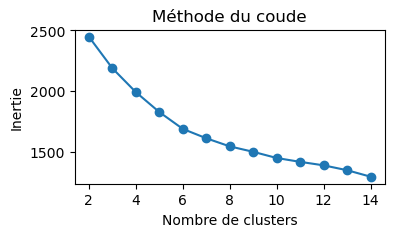

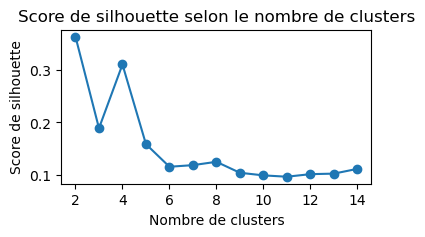

In [43]:
plt.figure(figsize=(4,2))
plt.plot(K_range, inerties, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Méthode du coude")

plt.figure(figsize=(4,2))
plt.plot(K_range, silhouettes, marker='o')
plt.xlabel("Nombre de clusters")
plt.ylabel("Score de silhouette")
plt.title("Score de silhouette selon le nombre de clusters")

plt.show()

In [78]:
for k in [2, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_prepared)
    
    print(f"\nNombre de clusters : {k}")
    print(f"Score de silhouette : {silhouette_score(X_prepared, labels):.3f}")
    
    df_temp = df.copy()
    df_temp["cluster"] = labels
    moyennes = df_temp.groupby("cluster")[variables_num].mean()
    effectifs = df_temp.groupby("cluster").size().rename("effectif")
    proportions = (effectifs / len(df_temp) * 100).rename("proportion_%")
    resume_clusters = pd.concat([effectifs, proportions, moyennes], axis=1).round(2)

    display(resume_clusters)
    



Nombre de clusters : 2
Score de silhouette : 0.363


,effectif,proportion_%,likes,prix,prix_moyen_zara,decote
cluster,,,,,,
0,337,87.76,21.82,9.77,33.39,0.63
1,47,12.24,82.68,44.25,31.29,-0.73



Nombre de clusters : 4
Score de silhouette : 0.310


,effectif,proportion_%,likes,prix,prix_moyen_zara,decote
cluster,,,,,,
0,33,8.59,107.97,32.45,29.10,-0.25
1,322,83.85,21.29,10.00,29.56,0.61
2,18,4.69,31.11,12.33,108.44,0.89
3,11,2.86,23.64,78.27,26.69,-2.29


In [53]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_prepared)

In [54]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_prepared.toarray() if hasattr(X_prepared, "toarray") else X_prepared)

df_cluster['ACP1'] = X_pca[:, 0]
df_cluster['ACP2'] = X_pca[:, 1]

In [56]:
print(f"Les deux premiers axes expliquent {pca.explained_variance_ratio_.sum()*100:.2f}% de la variance.")

Les deux premiers axes expliquent 43.29% de la variance.


In [58]:
feature_names = preprocessor.get_feature_names_out()

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=['ACP1', 'ACP2']
)

In [71]:
loadings['ACP1'].abs().sort_values(ascending=False).head(10)

num__decote                      0.641375
num__prix                        0.628802
num__likes                       0.299745
num__prix_moyen_zara             0.169468
cat__collection_homme            0.104764
cat__etat_neuf avec étiquette    0.103773
cat__collection_fille            0.093261
cat__matiere_cuir                0.077419
cat__collection_garçon           0.072260
cat__etat_très bon état          0.065825
Name: ACP1, dtype: float64

In [70]:
loadings['ACP2'].abs().sort_values(ascending=False).head(10)

num__prix_moyen_zara                        0.859879
num__likes                                  0.339203
cat__collection_homme                       0.234521
num__prix                                   0.168242
cat__categorie_hauts et t-shirts            0.113676
cat__collection_garçon                      0.095129
cat__categorie_blazers et tailleurs         0.082201
cat__collection_fille                       0.079649
cat__matiere_fibres naturelles végétales    0.075502
num__decote                                 0.070492
Name: ACP2, dtype: float64

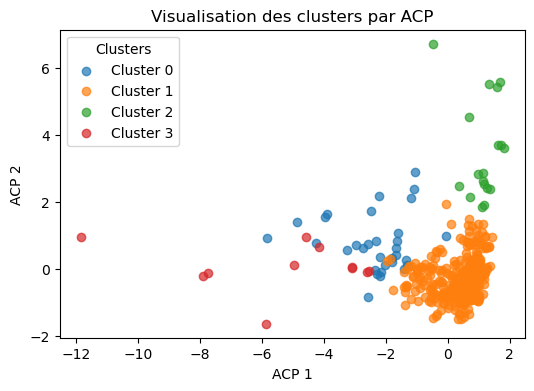

In [77]:
plt.figure(figsize=(6,4))
for cluster in sorted(df_cluster['cluster'].unique()):
    subset = df_cluster[df_cluster['cluster'] == cluster]
    plt.scatter(
        subset['ACP1'],
        subset['ACP2'],
        label=f'Cluster {cluster}',
        alpha=0.7
    )
plt.xlabel("ACP 1")
plt.ylabel("ACP 2")
plt.title("Visualisation des clusters par ACP")
plt.legend(title="Clusters")
plt.show()